# STA 141A: Wildfire Prediction Final Project

## Siyuan Ni


## 1. Abstract



## 2. Introduction
Since 2000, there has been around 70 thousands fires yearly burning an average of 7 million acres in the United States. These incidents occur due to a multitude of factors, including weather conditions, temperature, fuel availability, or even human-caused. This project aims to create a prediction model for future wildfires by analyzing past wildfires that have occured in the United States between 1992 and 2015.

## 3. Data Preprocessing

In this section, the dataset is reconstructed before analysis. A subset of the [full dataset](https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires/data) with 1.88 million entries of wildfires is used for this project. By subsetting the dataset, it optimizes the productivity and allows fasting running.


In [1]:
suppressMessages({
  library(tidyverse)
  library(maps)
  library(lubridate)
  library(viridis)
})

wildfires <- read.csv(file = "/Users/lucyn/OneDrive/STA 141A/Project/wildfires_sample_100k.csv")

###  Understanding the Dataset



As seen in the summary below, the dataset contains 100,000 entries with 39 distinct variables, along with their names and data types.


In [2]:
suppressMessages(glimpse(wildfires))

Rows: 100,000
Columns: 39
$ OBJECTID                   <int> 16, 68, 73, 111, 191, 228, 264, 269, 294, 3…
$ FOD_ID                     <int> 16, 68, 74, 112, 194, 231, 268, 274, 299, 3…
$ FPA_ID                     <chr> "FS-1418876", "FS-1419017", "FS-1419045", "…
$ SOURCE_SYSTEM_TYPE         <chr> "FED", "FED", "FED", "FED", "FED", "FED", "…
$ SOURCE_SYSTEM              <chr> "FS-FIRESTAT", "FS-FIRESTAT", "FS-FIRESTAT"…
$ NWCG_REPORTING_AGENCY      <chr> "FS", "FS", "FS", "FS", "FS", "FS", "FS", "…
$ NWCG_REPORTING_UNIT_ID     <chr> "USCAENF", "USMTKNF", "USMTKNF", "USCASNF",…
$ NWCG_REPORTING_UNIT_NAME   <chr> "Eldorado National Forest", "Kootenai Natio…
$ SOURCE_REPORTING_UNIT      <chr> "0503", "0114", "0114", "0515", "0302", "03…
$ SOURCE_REPORTING_UNIT_NAME <chr> "Eldorado National Forest", "Kootenai Natio…
$ LOCAL_FIRE_REPORT_ID       <chr> "103", "43", "33", "2", "279", "16", "37", …
$ LOCAL_INCIDENT_ID          <chr> "22", "015", "008", "01", "279", "06", "014…
$ FIRE_CODE   


The code below identifies any variables with substantial missing values and creates a table that reports the percentage of entries missing.

In [3]:
na_counts <- colSums(is.na(wildfires)) %>% sort(decreasing = TRUE)
na_df <- na_counts %>%
  tibble(col_name = names(na_counts), count = .) %>%
  mutate(percentage = count / nrow(wildfires)) %>%
  filter(count > 0)

na_df$percentage <- scales::percent(na_df$percentage)
na_df

col_name,count,percentage
<chr>,<dbl>,<chr>
COMPLEX_NAME,99751,99.75%
MTBS_ID,99423,99.42%
MTBS_FIRE_NAME,99423,99.42%
ICS_209_INCIDENT_NUMBER,98634,98.63%
ICS_209_NAME,98634,98.63%
FIRE_CODE,82815,82.82%
LOCAL_FIRE_REPORT_ID,77654,77.65%
CONT_TIME,51813,51.81%
FIRE_NAME,51227,51.23%


 Some variable have a large number of missing entries as seen in the table above, such as the name of complex, name of incident from the ICS 209 report and containment date. This could be due to the fact that these data were not recorded since the size of wildfire was small, or in the case of containment date, the fire might not have an official containment date. With these high missing percentage numbers, these variables would not be suitable to use for analysis.

### Temporal Patterns

`FIRE_DATE` is created from `FIRE_YEAR` and `DISCOVERY_DOY`.

In [10]:
fires <- wildfires %>%
  mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"))

#range(wildfires$FIRE_DATE, na.rm = TRUE)

fires %>%
  select(FIRE_DATE, FIRE_YEAR, DISCOVERY_DOY) %>% head()


,FIRE_DATE,FIRE_YEAR,DISCOVERY_DOY
,<date>,<int>,<int>
1,2005-07-16,2005,197
2,2005-07-17,2005,198
3,2005-08-07,2005,219
4,2005-08-05,2005,217
5,2005-08-12,2005,224
6,2005-09-03,2005,246


**(b)** Plot annual number of wildfires by year.


**(c)** Plot average fire size per year by year. 

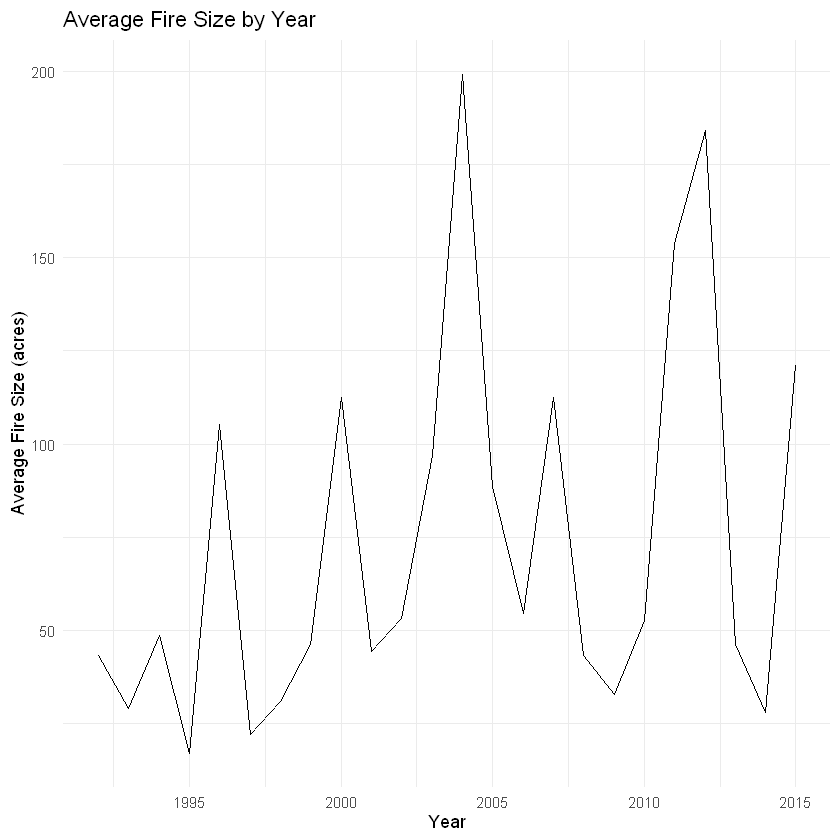

In [14]:
fire_size_per_year <- wildfires %>%
  group_by(FIRE_YEAR) %>%
  summarise(avg_fire_size = mean(FIRE_SIZE, na.rm = TRUE))

ggplot(fire_size_per_year, aes(x = FIRE_YEAR, y = avg_fire_size)) +
  geom_line() +
  labs(title = "Average Fire Size by Year",
       x = "Year",
       y = "Average Fire Size (acres)") +
  theme_minimal()


**(d)** Write 3–5 sentences describing temporal trends.


There appears to be no clear trend in average fire size or the number of fires throughout the years. There seems to be a lot of spikes in the plot of average fire sizes, which means that some extreme weather events could have caused larger fires in those years. From the annual number of fires, it can be seen that the data also varies greatly with clear spikes. This pattern could be explained by the fact that the years with high fire frequency reduces the fuel available for the next years, which would lower the number of fires occuring in the following years.

### Selecting notable fire threshold

Since the dataset contains records of fires that were small and contained quickly, including them for modeling would cause class imbalance. Therefore, we created a threshold and determined that fires are considered "notable" when their size is **greater than or equal to 300 acres**. This is consistent with U.S. Fire Department Agencies' wildfire reporting standards, as large wildland fires are commonly defined as 100 acres in timber fuel models, or   300 acres in grass or brush fuel models.

In [12]:
notable_fire_acres <- 300

notable_fires <- fires %>%
  filter(FIRE_SIZE >= notable_fire_acres)

cat("Number of notable fires:", nrow(notable_fires))

Number of notable fires: 1381

## 4. Exploratory Data Analysis

### Exploring Temporal Patterns

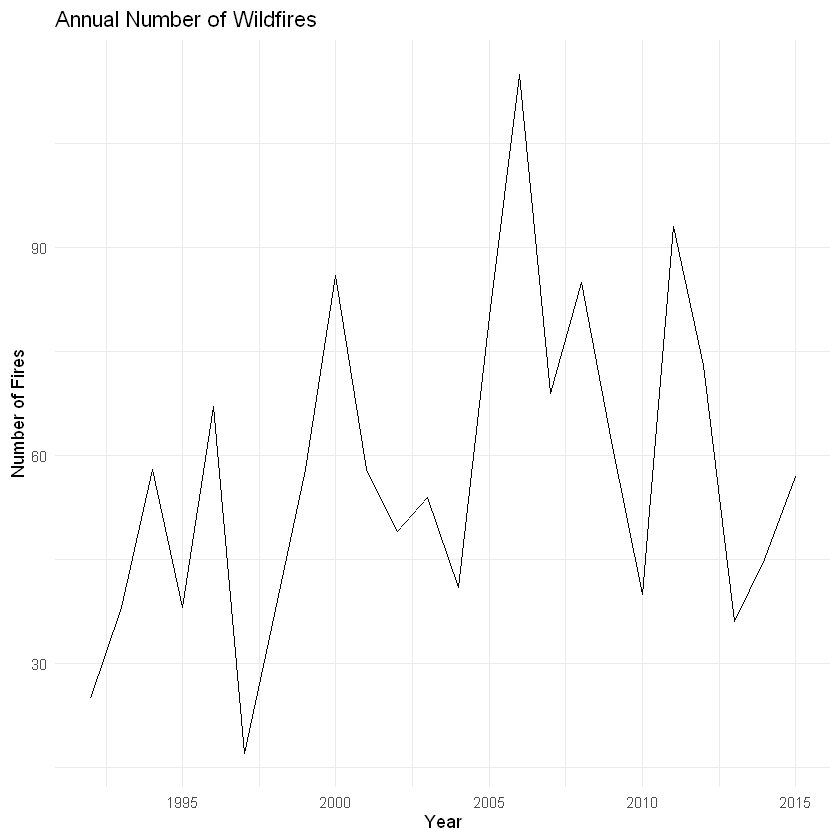

In [14]:
annual_fires <- wildfires %>% count(FIRE_YEAR)

ggplot(annual_fires, aes(x = FIRE_YEAR, y = n)) +
  geom_line() +
  labs(title = "Annual Number of Wildfires",
       x = "Year",
       y = "Number of Fires") +
  theme_minimal()

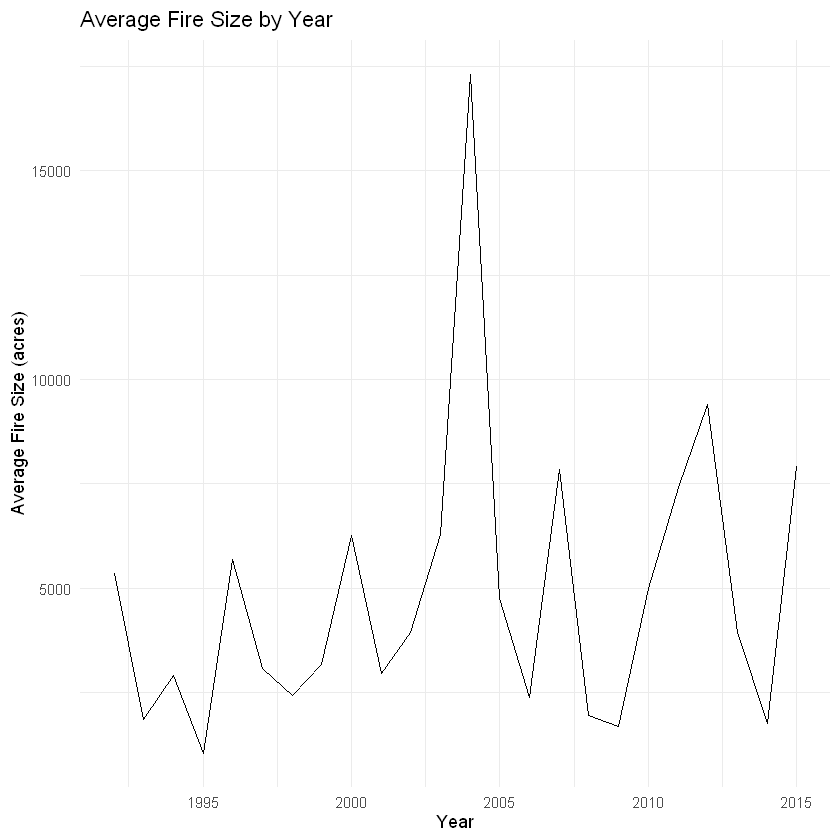

In [13]:
fire_size_per_year <- wildfires %>%
  group_by(FIRE_YEAR) %>%
  summarise(avg_fire_size = mean(FIRE_SIZE, na.rm = TRUE))

ggplot(fire_size_per_year, aes(x = FIRE_YEAR, y = avg_fire_size)) +
  geom_line() +
  labs(title = "Average Fire Size by Year",
       x = "Year",
       y = "Average Fire Size (acres)") +
  theme_minimal()

### Exploring Spatial Patterns


**(a)** Create a table of fire counts per `STATE` and report the top 10 states.


In [15]:
fires_by_state <- wildfires %>%
  count(STATE, sort = TRUE)

top10_states <- fires_by_state %>%
  slice_head(n = 10)

top10_states


STATE,n
<chr>,<int>
CA,10089
GA,8899
TX,7545
NC,5815
FL,4814
NY,4353
SC,4320
MS,4246
AZ,3722


**(b)** Make a horizontal bar plot of the top 10 states.

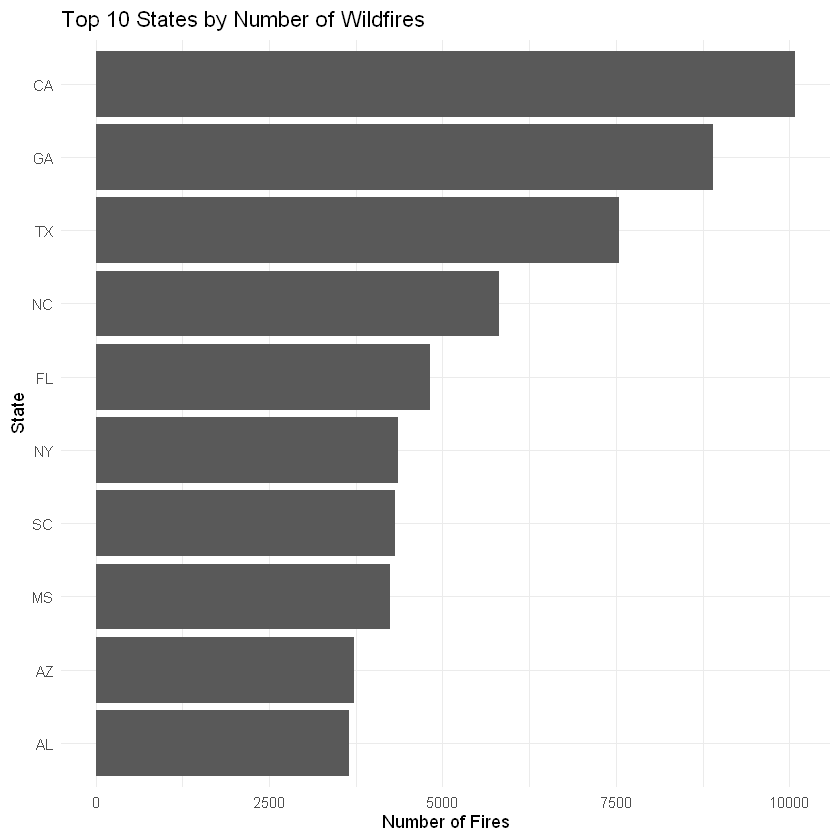

In [17]:
# Task 3(b): bar plot for top 10 states
ggplot(top10_states, aes(x = reorder(STATE, n), y = n)) +
  geom_col() +
  coord_flip() +
  labs(title = "Top 10 States by Number of Wildfires",
       x = "State",
       y = "Number of Fires") +
  theme_minimal()


**(c)** Make a scatterplot of ignition points (`LONGITUDE` vs `LATITUDE`).


In [ ]:
ggplot(wildfires, aes(x = LONGITUDE, y = LATITUDE, color = STATE)) +
  geom_point(alpha = 0.2, size = 0.5) +
    coord_equal() +
  labs(title = "Spatial Distribution of Wildfire Ignition Points",
       x = "Longitude",
       y = "Latitude") +
  theme_minimal()


**(d)** Comment briefly on geographic patterns. Optional: you may find it helpful to draw the boundaries of states. 

From the plot, it can be seen that wildfires are concentrated in the western states such as California and Oregon, which can be due to their dry climates and vegetation. The southeastern states, such as Georgia, Florida, and North Carolina, also seem to have concentrated clusters, which can be caused by denser vegetations.

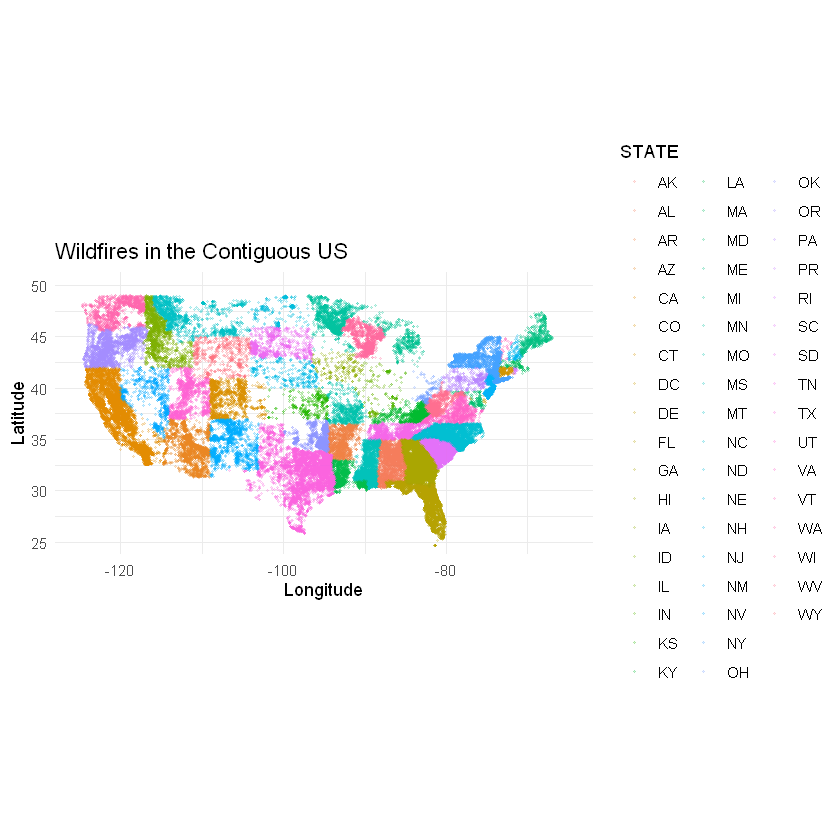

In [20]:
ggplot(wildfires, aes(x = LONGITUDE, y = LATITUDE, color = STATE)) +
  geom_point(alpha = 0.2, size = 0.5) +
    coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
  labs(title = "Wildfires in the Contiguous US",
       x = "Longitude",
       y = "Latitude") +
  theme_minimal()


---
### Task 4 Fire Size Distribution



**(a)** Plot a histogram of `FIRE_SIZE` in log scale.

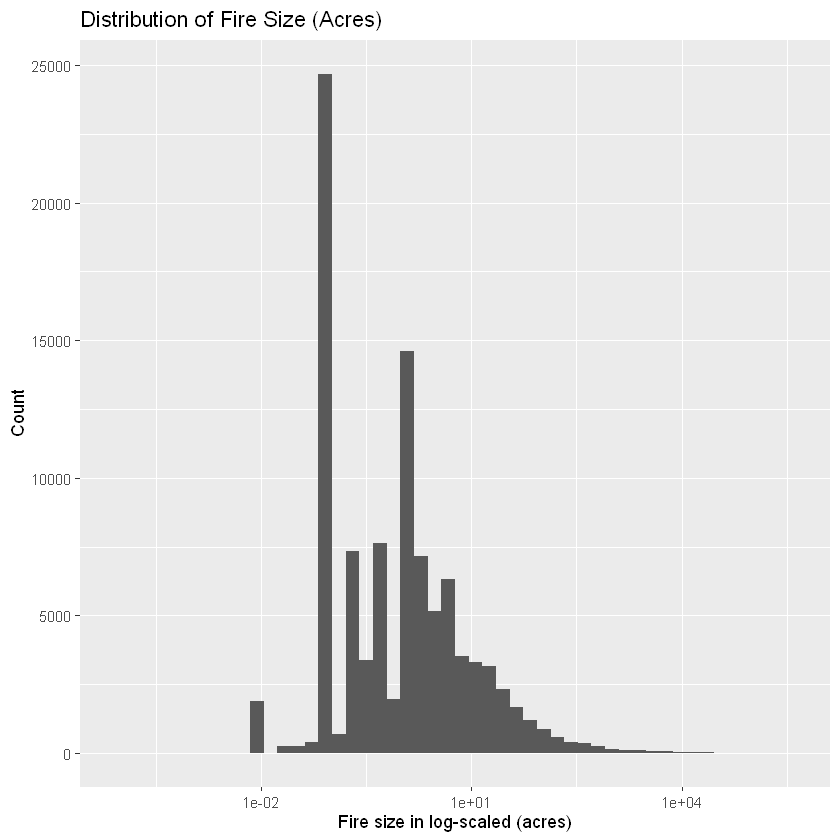

In [40]:
wildfires %>% ggplot(aes(x = FIRE_SIZE)) +
  geom_histogram(bins = 50) +
  scale_x_log10() +
  labs(title = "Distribution of Fire Size (Acres)",
       x = "Fire size in log-scaled (acres)", y = "Count")

**(b)** Create a boxplot of `FIRE_SIZE` by `FIRE_SIZE_CLASS`.


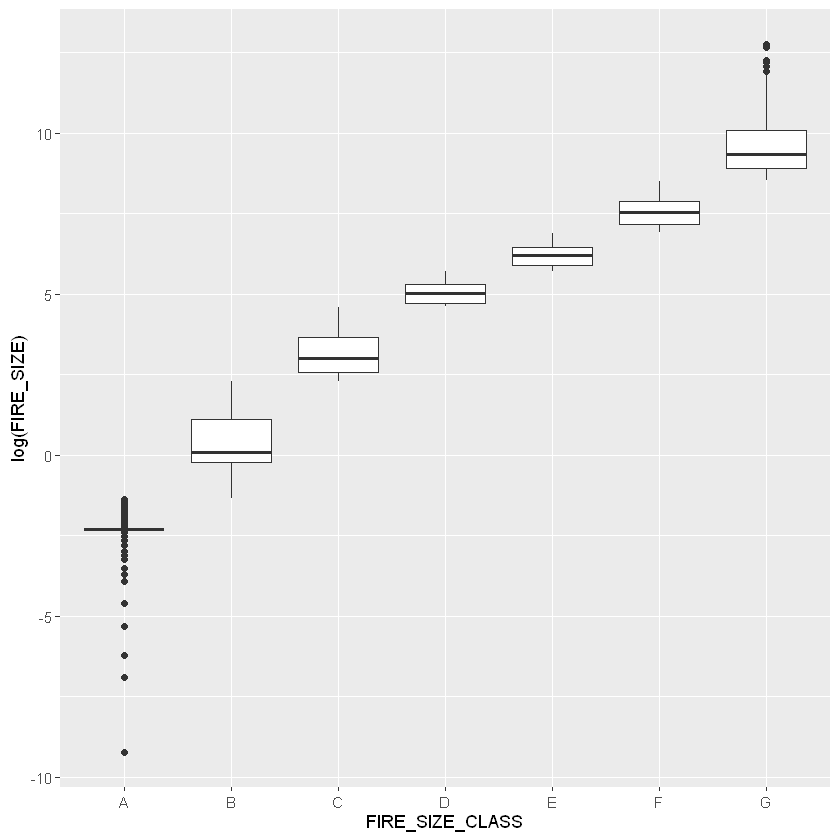

In [39]:
ggplot(wildfires) +
  geom_boxplot(aes(
    x = FIRE_SIZE_CLASS,
    y = log(FIRE_SIZE)
  ))


**(c)** Compute the median, 90th percentile, and 99th percentile of `FIRE_SIZE`.


In [38]:
wildfires %>%
  summarise(
    median = median(FIRE_SIZE, na.rm = TRUE),
    percentile_90 = quantile(FIRE_SIZE, 0.9, na.rm = TRUE),
    percentile_99 = quantile(FIRE_SIZE, 0.99, na.rm = TRUE)
  )

median,percentile_90,percentile_99
<dbl>,<dbl>,<dbl>
1,17,480



**(d)** Write 3–4 sentences interpreting the distribution and what it suggests for prediction tasks.


It can be seen from the percentiles that the firesize data seems to be right skewed, with half of the wildfires being less than or equal to 1 acres and the top 10 percent of wildfires being larger than 17 acres. Therefore, log-transformation is neccessary when plotting the fire size data and should be used for prediction tasks when it comes to fire sizes. It could also be helpful to predict by fire size classes, since the median of the fire size increases as fire size class increases.

---

### Task 5 Visualizing Fire Size Patterns

**(a)** Create a visualization that illustrates both the spatial and temporal patterns of fire sizes across U.S. states and years. Specifically, construct a heatmap with `STATE` on the y-axis, `FIRE_YEAR` on the x-axis, and the median `FIRE_SIZE` within each state–year combination represented by color intensity. 

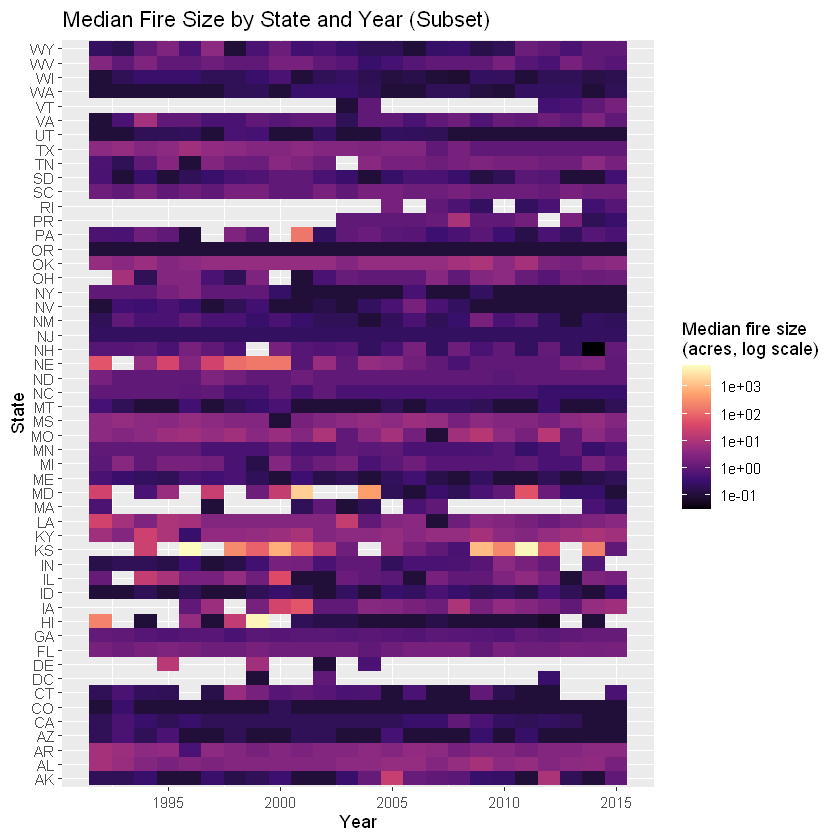

In [54]:
tempdata <- wildfires %>%
  group_by(STATE, FIRE_YEAR)

state_year_summary <- wildfires %>%
  group_by(STATE, FIRE_YEAR) %>%
  summarise(
    median_size = median(FIRE_SIZE, na.rm = TRUE),
    mean_size   = mean(FIRE_SIZE, na.rm = TRUE),
    n_fires     = n(),
    .groups = "drop"
  )

state_year_summary %>% ggplot(aes(x = FIRE_YEAR, y = STATE, fill = median_size)) +
  geom_tile(color = NA) +
  scale_fill_viridis_c(option = "magma", trans = "log10") +
  labs(
    title  = "Median Fire Size by State and Year (Subset)",
    x      = "Year",
    y      = "State",
    fill   = "Median fire size\n(acres, log scale)"
  )


**(b)** Briefly interpret the visualization. Your interpretation should describe any noticeable spatial differences across states, temporal trends over years, or other meaningful patterns observed in the plot.

From this heat map, it can be seen that some states have consistently large median fire sizes, such as Oregon, California, Arizona, and Colorado. States such as Rhode Island and Vermont seems to have no fire size data in the earlier years, which could indicate no fire that occured in those states. Overall, it can be concluded that most states have similar median fire sizes over the years, which can be explain by the state's climate, vegetation, and geography.

---
### Task 6  Designing Your Own Visualization

**(a)** Create an additional visualization of your own choosing that also highlights spatial and temporal information in fire sizes across states and years.  

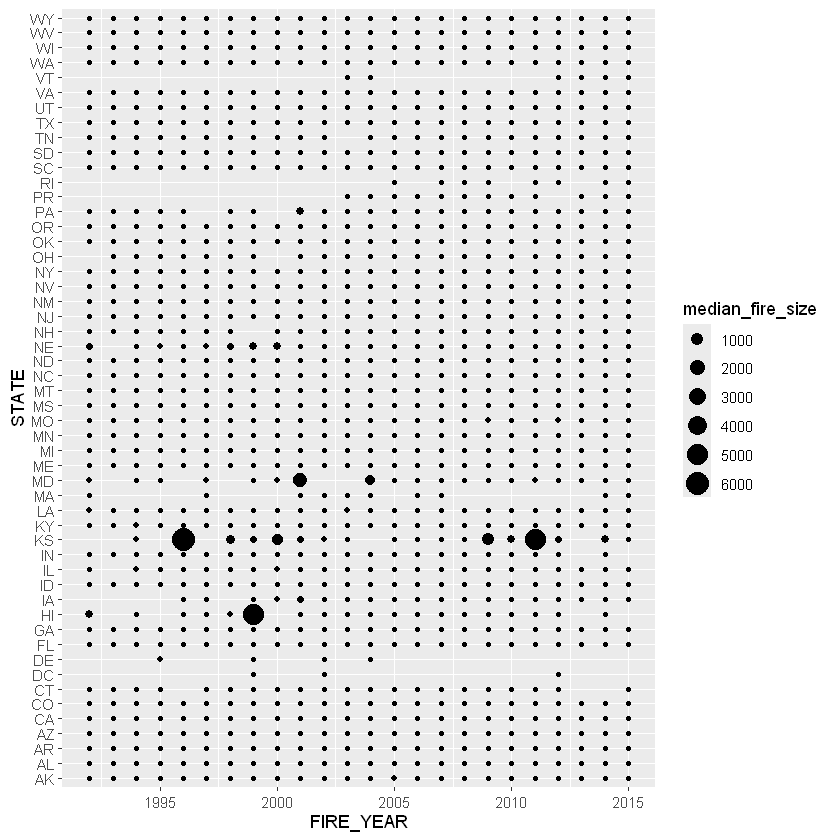

In [60]:
fire_size_group <- wildfires %>%
  group_by(STATE, FIRE_YEAR) %>%
  summarise(
    median_fire_size = median(FIRE_SIZE, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(fire_size_group,
       aes(FIRE_YEAR, STATE, size = median_fire_size)) +
  geom_point(alpha = 1)

## References
Wildfire data in Introduction: https://www.congress.gov/crs-product/IF10244
